# ALMA Published Wind Rose Plots

This notebook generates polar scatter wind rose plots for the ALMA ground-based meteorological data (`alma_published/*.met` files).

**Plot style** matches `structures/plots.ipynb`:
- Each data point is one scatter dot on a polar axis
- **Radius** = wind speed (m/s)
- **Angle** = wind direction (meteorological: N=0°, clockwise)
- **Color** = wind speed (viridis colormap)

**Output:** 25 plots total
- 24 monthly plots: `wsb_0101` → Jan 2001 … `wsb_0212` → Dec 2002
- 1 combined plot: all data from both years merged

**Notes on data quality:**
- Rows where direction σ ≥ 100° indicate a stuck/unreliable direction sensor (flagged as 225° SW). These are excluded from wind roses but their **speeds are still used in the statistics table**.
- Some months have no direction data at all (direction sensor offline). Those months show NaN for rose-based stats but valid speed statistics.

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ── Path to the published .met files ──────────────────────────
ALMA_DIR   = os.path.abspath(r"..\data\raw\alma_published")

# ── Export directory for saved plots ─────────────────────────
EXPORT_DIR = os.path.abspath(r"..\data\exports\alma_published_wind_roses")
os.makedirs(EXPORT_DIR, exist_ok=True)
print(f"Plots will be saved to: {EXPORT_DIR}")

# ── Column indices (0-based) ──────────────────────────────────
COL_SPEED     = 7    # wind speed in m/s
COL_DIRECTION = 10   # wind direction in degrees (meteorological)
COL_DIR_STD   = 11   # wind direction standard deviation (degrees)
MISSING       = -999
DIR_STD_MAX   = 100  # flag threshold: σ ≥ 100° → direction unreliable

# ── Plot style ────────────────────────────────────────────────
CMAP     = "viridis"
DOT_SIZE = 8
ALPHA    = 0.7

# Month names for titles
MONTH_NAMES = {
    '01': 'January',  '02': 'February', '03': 'March',
    '04': 'April',    '05': 'May',       '06': 'June',
    '07': 'July',     '08': 'August',    '09': 'September',
    '10': 'October',  '11': 'November',  '12': 'December'
}

# Year mapping: filename prefix → calendar year
YEAR_MAP = {'01': '2001', '02': '2002'}

print(f"Looking for .met files in: {ALMA_DIR}")
files = sorted(glob.glob(os.path.join(ALMA_DIR, "wsb_*.met")))
print(f"Found {len(files)} files:")
for f in files:
    print(" ", os.path.basename(f))

Plots will be saved to: C:\Users\2021n\Downloads\era5_wind_data_analysis\data\exports\alma_published_wind_roses
Looking for .met files in: C:\Users\2021n\Downloads\era5_wind_data_analysis\data\raw\alma_published
Found 24 files:
  wsb_0101.met
  wsb_0102.met
  wsb_0103.met
  wsb_0104.met
  wsb_0105.met
  wsb_0106.met
  wsb_0107.met
  wsb_0108.met
  wsb_0109.met
  wsb_0110.met
  wsb_0111.met
  wsb_0112.met
  wsb_0201.met
  wsb_0202.met
  wsb_0203.met
  wsb_0204.met
  wsb_0205.met
  wsb_0206.met
  wsb_0207.met
  wsb_0208.met
  wsb_0209.met
  wsb_0210.met
  wsb_0211.met
  wsb_0212.met


In [2]:
# ============================================================
# HELPER: parse a single .met file
# Returns TWO sets of arrays:
#   speed_all  – all valid wind speeds (col 7 ≠ -999, ≥ 0)
#                used for statistics (even when direction is missing)
#   speed_rose – speeds where direction is also valid AND reliable
#   dir_rose   – corresponding directions (σ < DIR_STD_MAX)
#                used for wind rose plots only
# ============================================================
def load_met(filepath):
    """
    Load an ALMA .met file and return clean arrays.

    Returns
    -------
    speed_all  : 1-D array of all valid wind speeds (m/s)
    speed_rose : 1-D array of speeds paired with reliable directions
    dir_rose   : 1-D array of corresponding reliable directions (°)
    """
    spd_col = []
    drn_col = []
    std_col = []

    with open(filepath, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            # Need at least cols 0..11
            if len(parts) <= max(COL_SPEED, COL_DIRECTION, COL_DIR_STD):
                continue
            try:
                spd = float(parts[COL_SPEED])
                drn = float(parts[COL_DIRECTION])
                std = float(parts[COL_DIR_STD])
            except ValueError:
                continue
            spd_col.append(spd)
            drn_col.append(drn)
            std_col.append(std)

    if not spd_col:
        return np.array([]), np.array([]), np.array([])

    spd_arr = np.array(spd_col, dtype=float)
    drn_arr = np.array(drn_col, dtype=float)
    std_arr = np.array(std_col, dtype=float)

    # ── speed_all: valid speed only (for statistics) ────────────
    valid_spd = (spd_arr != MISSING) & (spd_arr >= 0)
    speed_all = spd_arr[valid_spd]

    # ── speed_rose / dir_rose: need reliable direction too ───────
    # Exclude rows where direction = -999, speed = -999,
    # OR direction std ≥ DIR_STD_MAX (stuck sensor flagged at 225°)
    valid_rose = (
        (spd_arr != MISSING) & (spd_arr >= 0) &
        (drn_arr != MISSING) &
        (std_arr < DIR_STD_MAX)
    )
    speed_rose = spd_arr[valid_rose]
    dir_rose   = drn_arr[valid_rose]

    return speed_all, speed_rose, dir_rose

print("Helper loaded ✔")

Helper loaded ✔


In [3]:
# ============================================================
# HELPER: draw one wind rose scatter plot
# ============================================================
def plot_wind_rose(speed, direction, title, vmin=None, vmax=None,
                   figsize=(6, 6), save_path=None):
    """
    Draw a polar scatter wind rose.

    Parameters
    ----------
    speed     : array of wind speeds (m/s)  → radial distance
    direction : array of met directions (°) → angle (N=0, clockwise)
    title     : plot title string
    vmin/vmax : colorbar range (None = auto from data)
    save_path : if provided, save figure to this path before showing
    """
    if len(speed) == 0:
        print(f"  [SKIP] No valid rose data for: {title}")
        return

    theta = np.radians(direction)

    _vmin = vmin if vmin is not None else 0
    _vmax = vmax if vmax is not None else np.nanmax(speed)

    fig = plt.figure(figsize=figsize)
    ax  = fig.add_subplot(111, polar=True)

    sc = ax.scatter(
        theta, speed,
        c=speed, cmap=CMAP,
        vmin=_vmin, vmax=_vmax,
        s=DOT_SIZE, alpha=ALPHA, linewidths=0
    )

    # North at top, clockwise (meteorological convention)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # Cardinal direction labels
    ax.set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315],
                      ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])

    ax.set_ylabel("", labelpad=30)
    ax.set_rlabel_position(45)

    n_pts   = len(speed)
    mean_sp = np.mean(speed)
    max_sp  = np.max(speed)
    ax.set_title(
        f"{title}\nn={n_pts:,}  |  mean={mean_sp:.2f} m/s  |  max={max_sp:.2f} m/s",
        va='bottom', pad=20, fontsize=11, fontweight='bold'
    )

    cbar = plt.colorbar(sc, ax=ax, pad=0.12, shrink=0.7)
    cbar.set_label("Wind Speed (m/s)", fontsize=9)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved → {os.path.basename(save_path)}")

    plt.show()

print("Plot helper loaded ✔")

Plot helper loaded ✔


---
## 📅 Monthly Wind Roses (24 plots — one per .met file)

Files are named `wsb_YYMM.met` where `YY` is the year index (01=2001, 02=2002) and `MM` is the month (01–12).

> **Note:** Months where the direction sensor was offline the whole month will print `[SKIP]` for the rose but will still appear in the statistics table with valid speed data.

In [4]:
# ============================================================
# LOAD ALL FILES AND COLLECT DATA
# ============================================================
all_speed_rose = []   # for combined rose (direction-filtered)
all_dir_rose   = []
all_speed_all  = []   # for combined stats (speed-only)

monthly_data = []  # list of dicts per month

for filepath in files:
    basename = os.path.basename(filepath)          # e.g. wsb_0101.met
    code     = basename.replace('wsb_', '').replace('.met', '')  # '0101'
    yr_code  = code[:2]   # '01' or '02'
    mo_code  = code[2:]   # '01' .. '12'

    year  = YEAR_MAP.get(yr_code, f'20{yr_code}')
    month = MONTH_NAMES.get(mo_code, mo_code)
    label = f"ALMA Ground Station — {month} {year}"

    speed_all, speed_rose, dir_rose = load_met(filepath)

    monthly_data.append({
        'label':      label,
        'year':       year,
        'month':      month,
        'mo_code':    mo_code,
        'yr_code':    yr_code,
        'speed_all':  speed_all,   # all valid speeds (for stats)
        'speed_rose': speed_rose,  # direction-filtered speeds (for rose)
        'dir_rose':   dir_rose,    # reliable directions (for rose)
    })

    if len(speed_rose) > 0:
        all_speed_rose.append(speed_rose)
        all_dir_rose.append(dir_rose)
    if len(speed_all) > 0:
        all_speed_all.append(speed_all)

    print(f"  {basename}  →  {label}")
    print(f"      speed_all={len(speed_all):,} pts  |  "
          f"rose (dir-filtered)={len(speed_rose):,} pts")

# Global vmax from direction-filtered speeds for consistent colorbar
global_vmax = np.nanmax(np.concatenate(all_speed_rose)) if all_speed_rose else 20
print(f"\nGlobal max speed (rose data): {global_vmax:.2f} m/s")

  wsb_0101.met  →  ALMA Ground Station — January 2001
      speed_all=698 pts  |  rose (dir-filtered)=647 pts
  wsb_0102.met  →  ALMA Ground Station — February 2001
      speed_all=565 pts  |  rose (dir-filtered)=298 pts
  wsb_0103.met  →  ALMA Ground Station — March 2001
      speed_all=646 pts  |  rose (dir-filtered)=38 pts
  wsb_0104.met  →  ALMA Ground Station — April 2001
      speed_all=697 pts  |  rose (dir-filtered)=0 pts
  wsb_0105.met  →  ALMA Ground Station — May 2001
      speed_all=692 pts  |  rose (dir-filtered)=25 pts
  wsb_0106.met  →  ALMA Ground Station — June 2001
      speed_all=718 pts  |  rose (dir-filtered)=0 pts
  wsb_0107.met  →  ALMA Ground Station — July 2001
      speed_all=744 pts  |  rose (dir-filtered)=36 pts
  wsb_0108.met  →  ALMA Ground Station — August 2001
      speed_all=732 pts  |  rose (dir-filtered)=148 pts
  wsb_0109.met  →  ALMA Ground Station — September 2001
      speed_all=720 pts  |  rose (dir-filtered)=50 pts
  wsb_0110.met  →  ALMA Ground

  Saved → wsb_0101_January_2001.png


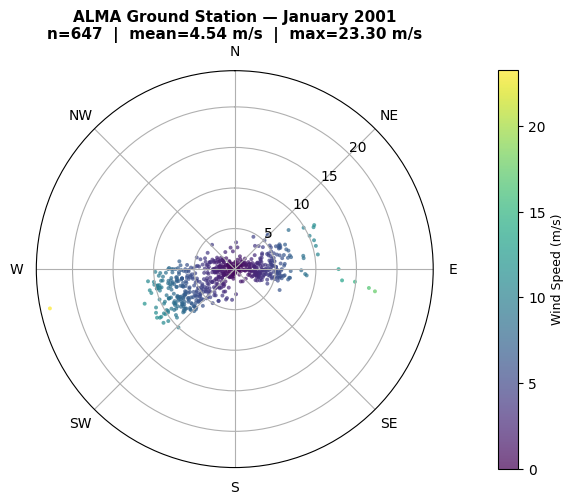

  Saved → wsb_0102_February_2001.png


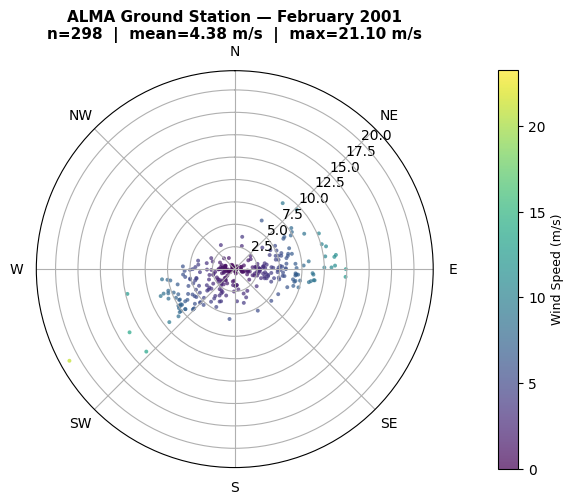

  Saved → wsb_0103_March_2001.png


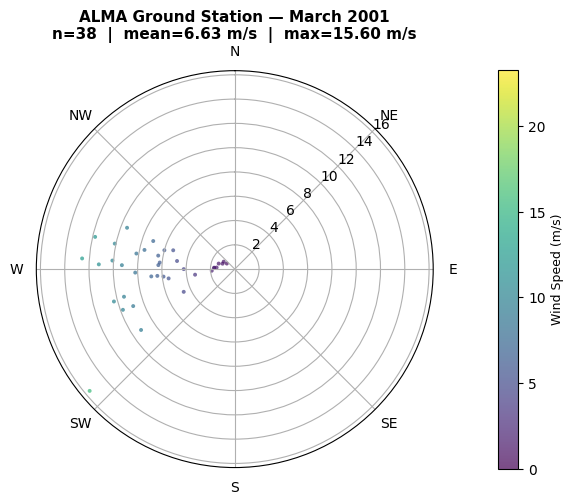

  [SKIP] No valid rose data for: ALMA Ground Station — April 2001


  Saved → wsb_0105_May_2001.png


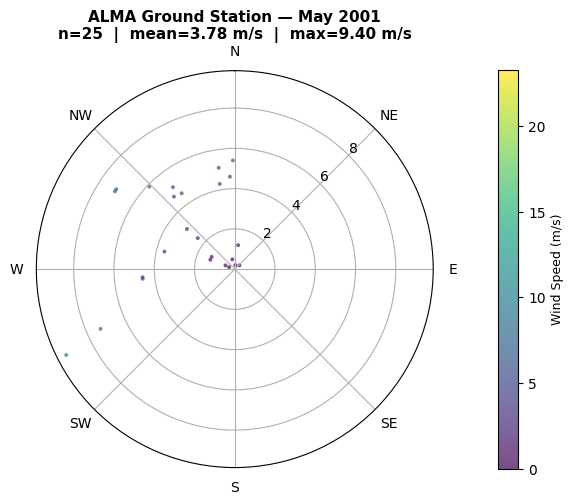

  [SKIP] No valid rose data for: ALMA Ground Station — June 2001


  Saved → wsb_0107_July_2001.png


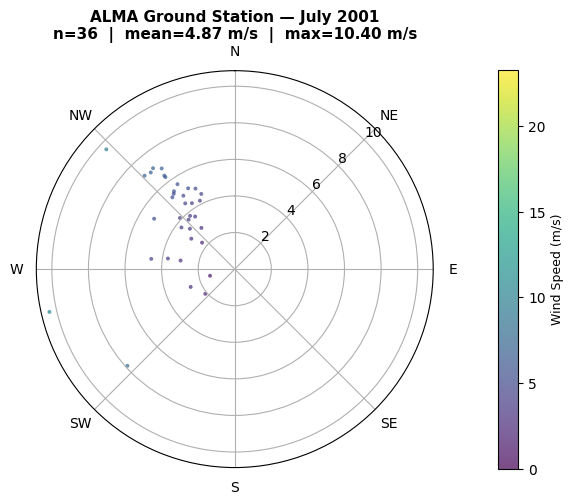

  Saved → wsb_0108_August_2001.png


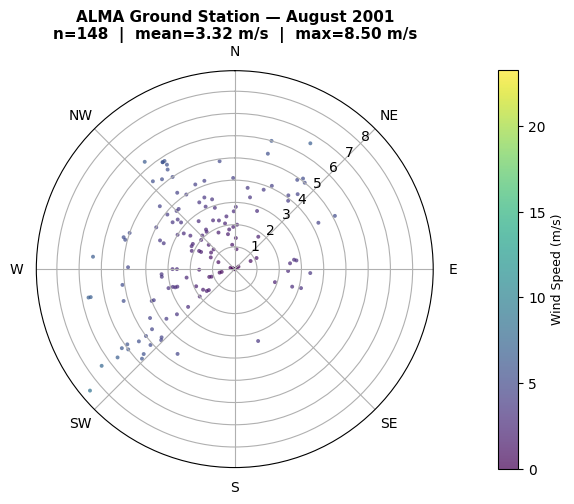

  Saved → wsb_0109_September_2001.png


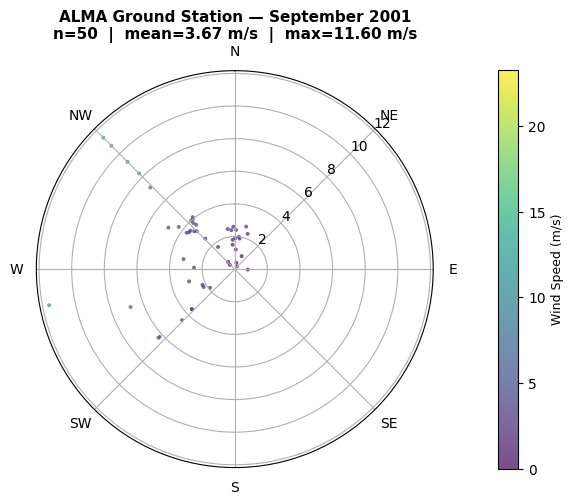

  Saved → wsb_0110_October_2001.png


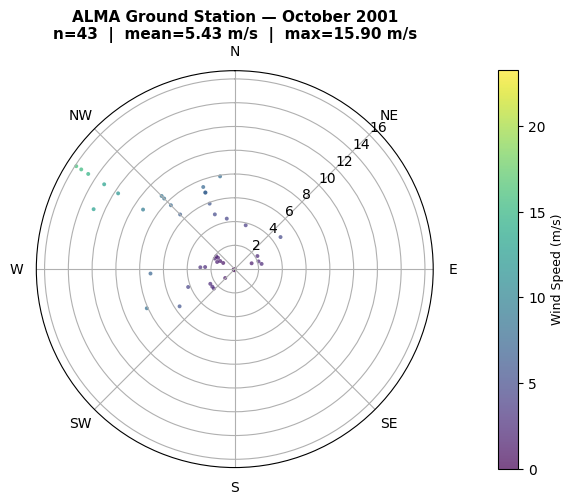

  Saved → wsb_0111_November_2001.png


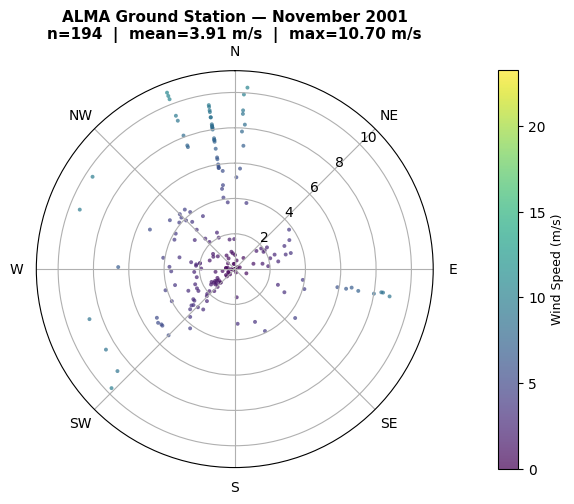

  Saved → wsb_0112_December_2001.png


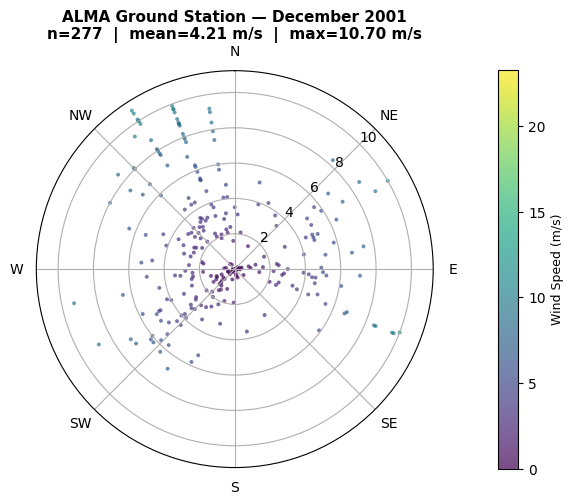

  Saved → wsb_0201_January_2002.png


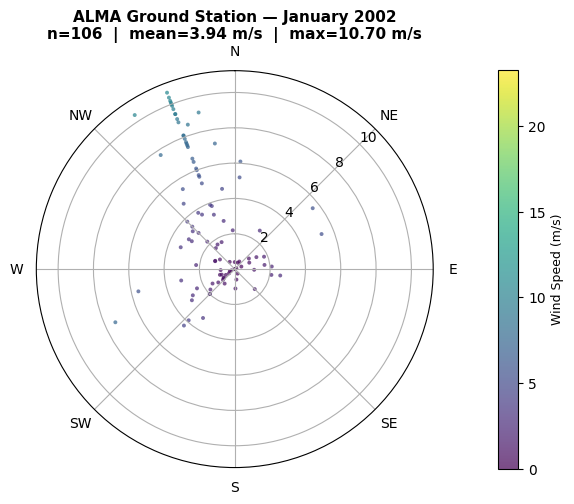

  [SKIP] No valid rose data for: ALMA Ground Station — February 2002
  [SKIP] No valid rose data for: ALMA Ground Station — March 2002
  [SKIP] No valid rose data for: ALMA Ground Station — April 2002
  [SKIP] No valid rose data for: ALMA Ground Station — May 2002


  Saved → wsb_0206_June_2002.png


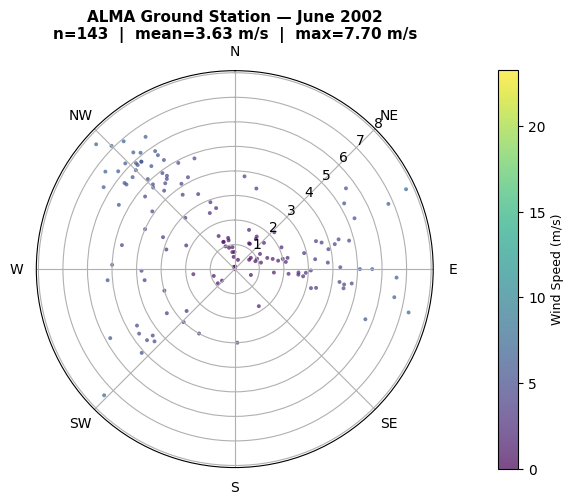

  [SKIP] No valid rose data for: ALMA Ground Station — July 2002
  [SKIP] No valid rose data for: ALMA Ground Station — August 2002
  [SKIP] No valid rose data for: ALMA Ground Station — September 2002
  [SKIP] No valid rose data for: ALMA Ground Station — October 2002
  [SKIP] No valid rose data for: ALMA Ground Station — November 2002
  [SKIP] No valid rose data for: ALMA Ground Station — December 2002


In [5]:
# ============================================================
# PLOT 1–24: ONE WIND ROSE PER MONTH  (saved to EXPORT_DIR)
# ============================================================
for entry in monthly_data:
    # Build a safe filename: e.g. wsb_0101_January_2001.png
    fname = f"wsb_{entry['yr_code']}{entry['mo_code']}_{entry['month']}_{entry['year']}.png"
    save_path = os.path.join(EXPORT_DIR, fname)

    plot_wind_rose(
        speed     = entry['speed_rose'],
        direction = entry['dir_rose'],
        title     = entry['label'],
        vmin      = 0,
        vmax      = global_vmax,
        save_path = save_path
    )

---
## 🌐 Combined Wind Rose (Plot 25 — All Data 2001–2002)

Combined rose dataset : 2,005 valid direction points
Combined speed (all)  : 15,632 valid speed points
  Speed (rose)  — mean: 4.26 m/s  |  max: 23.30 m/s
  Speed (all)   — mean: 6.55 m/s  |  max: 30.50 m/s


  Saved → combined_2001_2002_all.png


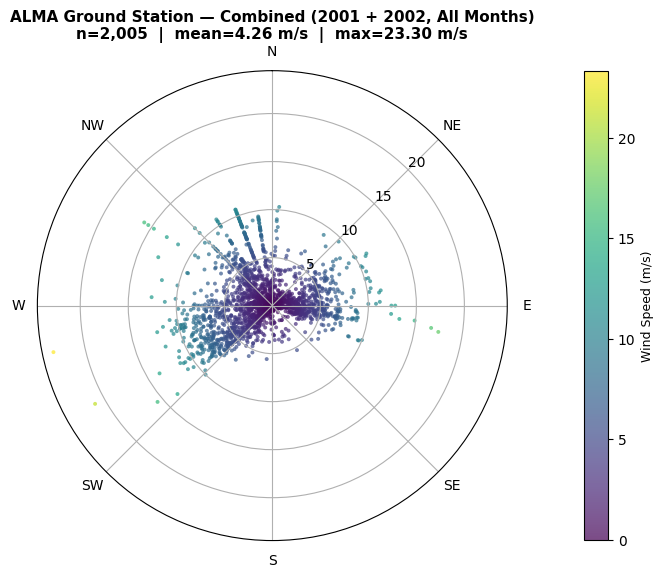

In [6]:
# ============================================================
# PLOT 25: COMBINED — ALL DATA 2001 + 2002  (saved to EXPORT_DIR)
# ============================================================
combined_speed_rose = np.concatenate(all_speed_rose)
combined_dir_rose   = np.concatenate(all_dir_rose)
combined_speed_all  = np.concatenate(all_speed_all)

print(f"Combined rose dataset : {len(combined_speed_rose):,} valid direction points")
print(f"Combined speed (all)  : {len(combined_speed_all):,} valid speed points")
print(f"  Speed (rose)  — mean: {np.mean(combined_speed_rose):.2f} m/s  |  "
      f"max: {np.max(combined_speed_rose):.2f} m/s")
print(f"  Speed (all)   — mean: {np.mean(combined_speed_all):.2f} m/s  |  "
      f"max: {np.max(combined_speed_all):.2f} m/s")

combined_save = os.path.join(EXPORT_DIR, "combined_2001_2002_all.png")

plot_wind_rose(
    speed     = combined_speed_rose,
    direction = combined_dir_rose,
    title     = "ALMA Ground Station — Combined (2001 + 2002, All Months)",
    vmin      = 0,
    vmax      = global_vmax,
    figsize   = (7, 7),
    save_path = combined_save
)

---
## 📊 Summary Statistics Table

- **N (all speeds)**: total valid wind speed readings, regardless of direction availability
- **N (rose)**: subset where direction was also reliable (used in wind roses)
- Speed statistics (mean, std, percentiles) are computed from **all valid speeds** so months where the direction sensor was down still contribute real data.

In [7]:
# ============================================================
# SUMMARY TABLE
# Speed stats use speed_all (not speed_rose) so months with
# a broken direction sensor still show meaningful statistics.
# ============================================================
rows = []
for entry in monthly_data:
    spd = entry['speed_all']   # ← all valid speeds
    n_rose = len(entry['speed_rose'])

    if len(spd) == 0:
        rows.append({
            'Period':        f"{entry['month']} {entry['year']}",
            'N (all speeds)': 0,
            'N (rose)':       n_rose,
            'Mean (m/s)':    np.nan,
            'Std (m/s)':     np.nan,
            'Max (m/s)':     np.nan,
            'P50 (m/s)':     np.nan,
            'P90 (m/s)':     np.nan,
            'P99 (m/s)':     np.nan,
        })
    else:
        rows.append({
            'Period':        f"{entry['month']} {entry['year']}",
            'N (all speeds)': len(spd),
            'N (rose)':       n_rose,
            'Mean (m/s)':    round(np.mean(spd), 3),
            'Std (m/s)':     round(np.std(spd), 3),
            'Max (m/s)':     round(np.max(spd), 3),
            'P50 (m/s)':     round(np.percentile(spd, 50), 3),
            'P90 (m/s)':     round(np.percentile(spd, 90), 3),
            'P99 (m/s)':     round(np.percentile(spd, 99), 3),
        })

# Combined row (all speed data)
rows.append({
    'Period':        'ALL 2001–2002',
    'N (all speeds)': len(combined_speed_all),
    'N (rose)':       len(combined_speed_rose),
    'Mean (m/s)':    round(np.mean(combined_speed_all), 3),
    'Std (m/s)':     round(np.std(combined_speed_all), 3),
    'Max (m/s)':     round(np.max(combined_speed_all), 3),
    'P50 (m/s)':     round(np.percentile(combined_speed_all, 50), 3),
    'P90 (m/s)':     round(np.percentile(combined_speed_all, 90), 3),
    'P99 (m/s)':     round(np.percentile(combined_speed_all, 99), 3),
})

summary_df = pd.DataFrame(rows)
summary_df

,Period,N (all speeds),N (rose),Mean (m/s),Std (m/s),Max (m/s),P50 (m/s),P90 (m/s),P99 (m/s)
0,January 2001,698,647,4.671,3.058,23.3,4.40,8.50,12.809
1,February 2001,565,298,4.793,3.324,28.5,4.60,8.00,15.176
2,March 2001,646,38,5.441,3.111,29.1,5.10,9.50,13.655
3,April 2001,697,0,6.149,3.845,20.7,5.80,11.44,14.800
4,May 2001,692,25,7.945,4.204,23.4,7.60,13.40,18.909
5,June 2001,718,0,6.477,4.246,18.4,5.65,12.63,17.566
6,July 2001,744,36,7.376,3.648,19.3,6.80,12.27,18.157
7,August 2001,732,148,6.839,3.868,23.9,5.95,12.30,18.628
8,September 2001,720,50,8.483,3.836,21.8,8.10,13.40,18.843
9,October 2001,375,43,8.178,3.735,19.5,7.60,13.40,17.226
